# Polynomial Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\soumi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


In [21]:
x = np.random.randn(100,1)*6
x.shape

(100, 1)

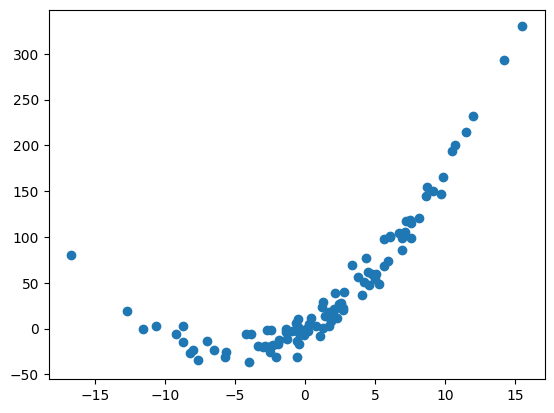

In [52]:
y = 0.8*x**2 + 9*x + np.random.randn(100,1)*10
plt.scatter(x, y)


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [54]:
X_train,X_test,y_train,y_test=train_test_split(x,y,train_size=0.75,random_state=42)


In [53]:
model = LinearRegression()
model.fit(x, y)

LinearRegression()

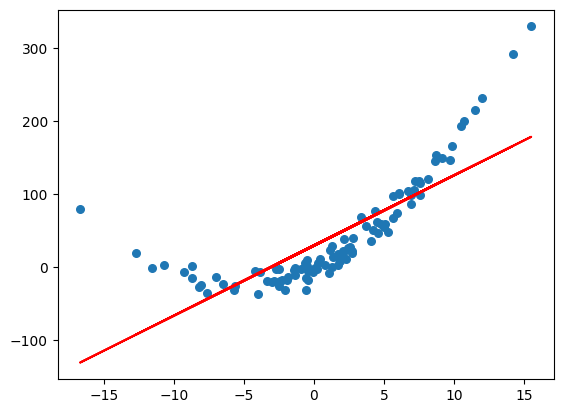

In [55]:
plt.scatter(x, y, s=30)
plt.plot(x, model.predict(x), color='r')

In [30]:
from sklearn.metrics import r2_score

In [56]:
score = r2_score(y, model.predict(x))
print("r2 score for linear regression model on polynomial dataset: ", score)

r2 score for linear regression model on polynomial dataset:  0.6280529108730323


In [57]:
from sklearn.preprocessing import PolynomialFeatures

In [58]:
poly = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly.fit_transform(x)
x_poly

array([[ 6.96437326e+00,  4.85024949e+01],
       [ 2.81990862e+00,  7.95188463e+00],
       [ 1.15230348e+01,  1.32780331e+02],
       [-2.96306428e+00,  8.77974996e+00],
       [ 1.74229045e+00,  3.03557601e+00],
       [ 7.88167054e-01,  6.21207305e-01],
       [-3.96424190e+00,  1.57152138e+01],
       [-8.19303733e+00,  6.71258606e+01],
       [-1.27378423e+01,  1.62252626e+02],
       [ 5.68080640e+00,  3.22715614e+01],
       [-6.51312602e+00,  4.24208105e+01],
       [ 1.06938675e+00,  1.14358802e+00],
       [ 8.67197479e+00,  7.52031467e+01],
       [ 1.71944014e+00,  2.95647439e+00],
       [ 1.83272394e+00,  3.35887703e+00],
       [ 5.09354257e+00,  2.59441759e+01],
       [-4.05864288e-01,  1.64725820e-01],
       [-8.71054197e+00,  7.58735413e+01],
       [-5.92443416e-01,  3.50989201e-01],
       [-4.90601494e-01,  2.40689826e-01],
       [ 6.05254050e+00,  3.66332465e+01],
       [-2.86521828e+00,  8.20947580e+00],
       [ 9.87226067e+00,  9.74615307e+01],
       [ 4.

In [59]:
poly_model = LinearRegression()
poly_model.fit(x_poly, y)

LinearRegression()

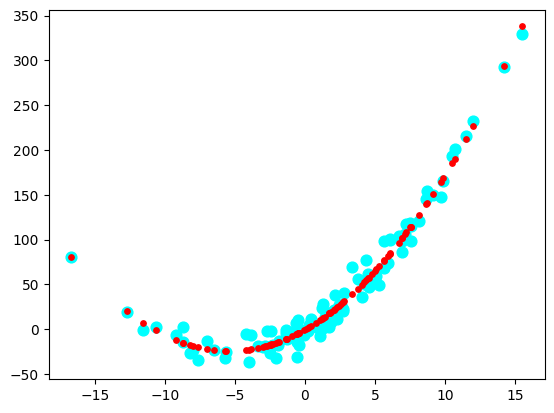

In [66]:
plt.scatter(x, y, s=60, alpha=1, color='cyan')
plt.scatter(x, poly_model.predict(x_poly), color='r', s=15)

In [68]:
score = r2_score(y, poly_model.predict(x_poly))
print("r2 score for linear regression model on polynomial dataset: ", score)

r2 score for linear regression model on polynomial dataset:  0.9787189179887692


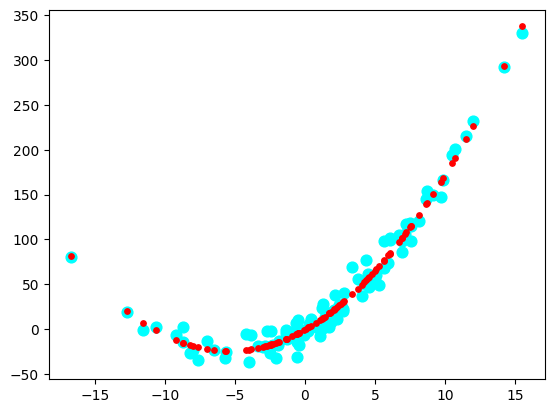

r2 score for linear regression model on polynomial dataset:  0.978719773994768


In [69]:
poly3 = PolynomialFeatures(degree=3, include_bias=False)
x_poly3 = poly3.fit_transform(x)
poly3_model = LinearRegression()
poly3_model.fit(x_poly3, y)
plt.scatter(x, y, s=60, alpha=1, color='cyan')
plt.scatter(x, poly3_model.predict(x_poly3), color='r', s=15)
plt.show()
score3 = r2_score(y, poly3_model.predict(x_poly3))
print("r2 score for linear regression model on polynomial dataset: ", score3)


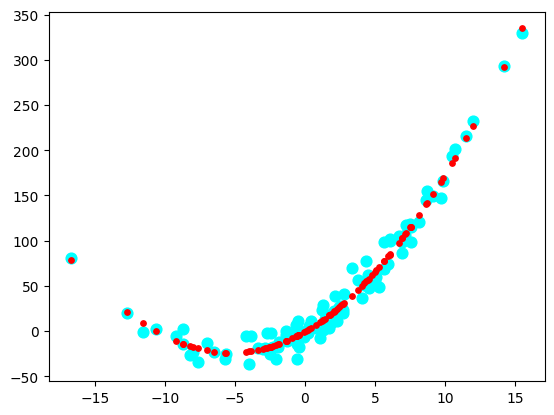

r2 score for linear regression model on polynomial dataset:  0.9788089136009006


In [70]:
poly4 = PolynomialFeatures(degree=4, include_bias=False)
x_poly4 = poly4.fit_transform(x)
poly4_model = LinearRegression()
poly4_model.fit(x_poly4, y)
plt.scatter(x, y, s=60, alpha=1, color='cyan')
plt.scatter(x, poly4_model.predict(x_poly4), color='r', s=15)
plt.show()
score4 = r2_score(y, poly4_model.predict(x_poly4))
print("r2 score for linear regression model on polynomial dataset: ", score4)


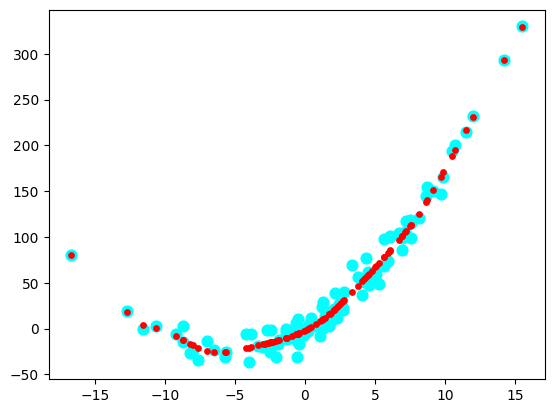

r2 score for linear regression model on polynomial dataset:  0.9794826924549109


In [72]:
poly12 = PolynomialFeatures(degree=12, include_bias=False)
x_poly12 = poly12.fit_transform(x)
poly12_model = LinearRegression()
poly12_model.fit(x_poly12, y)
plt.scatter(x, y, s=60, alpha=1, color='cyan')
plt.scatter(x, poly12_model.predict(x_poly12), color='r', s=15)
plt.show()
score12 = r2_score(y, poly12_model.predict(x_poly12))
print("r2 score for linear regression model on polynomial dataset: ", score12)

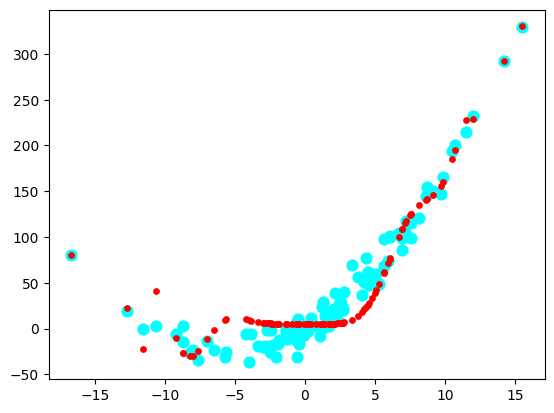

r2 score for linear regression model on polynomial dataset:  0.9201186986957017


In [85]:
poly16 = PolynomialFeatures(degree=16, include_bias=True)
x_poly16 = poly16.fit_transform(x)
poly16_model = LinearRegression()
poly16_model.fit(x_poly16, y)
plt.scatter(x, y, s=60, alpha=1, color='cyan')
plt.scatter(x, poly16_model.predict(x_poly16), color='r', s=15)
plt.show()
score16 = r2_score(y, poly16_model.predict(x_poly16))
print("r2 score for linear regression model on polynomial dataset: ", score16)

# Pipeline Concept

In [86]:
from sklearn.pipeline import Pipeline

In [111]:
def poly_regression(degree):
    X_new = np.linspace(X_test.min(), X_train.max(), 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    # plt.axis([-4,4, 0, 10])
    plt.show()


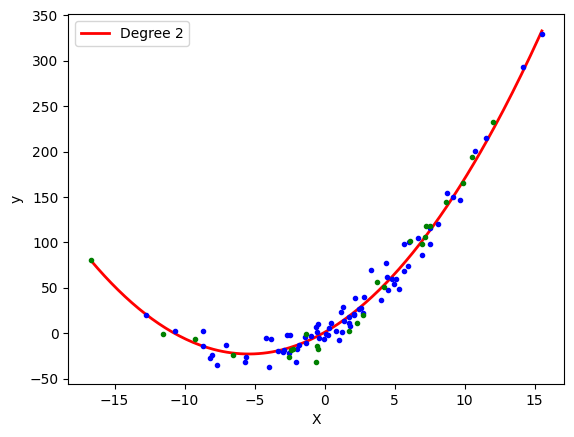

In [119]:
poly_regression(2)